# Retail Shelf SKU Dataset — Deep EDA Notebook

This notebook is the **first technical milestone** of the project.

Project goal: build a backend system that can detect retail shelf product facings, crop products, match each crop to a known SKU, flag uncertain/unknown products, and support few-shot new SKU onboarding.

This notebook focuses only on **data understanding and validation**. No model training is performed here.

## What this notebook answers

1. Is the dataset structurally valid?
2. Are images correctly paired with YOLO annotation files?
3. How many images, boxes, and classes do we have?
4. Are class IDs balanced or long-tailed?
5. Are bounding boxes reasonable in size and aspect ratio?
6. Are there very small / very large / suspicious boxes?
7. Are labels spatially concentrated in specific shelf regions?
8. Which classes are ready for 10/20/50-shot experiments?
9. What needs to be fixed before YOLO training?

## 0. Setup

Change `DATA_DIR` to your dataset path. The expected dataset format is:

```text
DATA_DIR/
  image_001.jpg
  image_001.txt
  image_002.jpg
  image_002.txt
```

YOLO annotation format:

```text
class_id x_center y_center width height
```

All coordinates are normalized between `0` and `1`.

In [ ]:
from pathlib import Path
import os
import math
import random
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adjusted to point to the actual retail shelf Lipton dataset
DATA_DIR = Path("../Transmed Lipton - Dataset")
OUTPUT_DIR = Path("../eda_outputs")
REPORT_DIR = Path("../reports")
PREVIEW_DIR = OUTPUT_DIR / "previews_deep"

for p in [OUTPUT_DIR, REPORT_DIR, PREVIEW_DIR]:
    p.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
random.seed(42)
np.random.seed(42)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


DATA_DIR: D:\Marwan\ITI AI&ML\Transmid GP\Transmed Lipton - Dataset
OUTPUT_DIR: D:\Marwan\ITI AI&ML\Transmid GP\eda_outputs


## 1. Scan images and label files

This section pairs every image with a `.txt` file and finds orphan files.

In [2]:
def scan_dataset(data_dir: Path):
    images = sorted([p for p in data_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])
    labels = sorted([p for p in data_dir.iterdir() if p.suffix.lower() == ".txt"])

    image_stems = {p.stem: p for p in images}
    label_stems = {p.stem: p for p in labels}

    paired = []
    missing_labels = []
    labels_without_images = []

    for stem, img_path in image_stems.items():
        label_path = label_stems.get(stem)
        if label_path is None:
            missing_labels.append(img_path)
        else:
            paired.append((img_path, label_path))

    for stem, label_path in label_stems.items():
        if stem not in image_stems:
            labels_without_images.append(label_path)

    return images, labels, paired, missing_labels, labels_without_images

images, labels, paired, missing_labels, labels_without_images = scan_dataset(DATA_DIR)

scan_summary = {
    "num_images": len(images),
    "num_label_files": len(labels),
    "num_paired_files": len(paired),
    "num_missing_labels": len(missing_labels),
    "num_labels_without_images": len(labels_without_images),
}
scan_summary

{'num_images': 1000,
 'num_label_files': 1000,
 'num_paired_files': 1000,
 'num_missing_labels': 0,
 'num_labels_without_images': 0}

## 2. Parse and validate YOLO annotations

Validation rules:

- Each row must have exactly 5 values.
- `class_id` must be an integer.
- `x_center`, `y_center`, `width`, `height` must be floats.
- Coordinates must be in `[0, 1]`.
- Width and height must be greater than `0`.
- Image must be readable by OpenCV.

In [3]:
def read_image_info(img_path: Path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    h, w = img.shape[:2]
    return {"image_width": w, "image_height": h, "channels": img.shape[2] if len(img.shape) == 3 else 1}


def parse_label_file(label_path: Path, image_info: dict, image_path: Path):
    rows = []
    errors = []

    if label_path.stat().st_size == 0:
        errors.append({
            "image_file": image_path.name,
            "label_file": label_path.name,
            "line_number": None,
            "issue_type": "empty_label_file",
            "raw_line": "",
        })
        return rows, errors

    lines = label_path.read_text(encoding="utf-8", errors="ignore").splitlines()
    for line_idx, raw_line in enumerate(lines, start=1):
        stripped = raw_line.strip()
        if not stripped:
            errors.append({
                "image_file": image_path.name,
                "label_file": label_path.name,
                "line_number": line_idx,
                "issue_type": "blank_annotation_row",
                "raw_line": raw_line,
            })
            continue

        parts = stripped.split()
        if len(parts) != 5:
            errors.append({
                "image_file": image_path.name,
                "label_file": label_path.name,
                "line_number": line_idx,
                "issue_type": "wrong_number_of_tokens",
                "raw_line": raw_line,
            })
            continue

        class_raw, x_raw, y_raw, w_raw, h_raw = parts
        try:
            class_id = int(class_raw)
        except ValueError:
            errors.append({
                "image_file": image_path.name,
                "label_file": label_path.name,
                "line_number": line_idx,
                "issue_type": "class_id_not_integer",
                "raw_line": raw_line,
            })
            continue

        try:
            x, y, bw, bh = map(float, [x_raw, y_raw, w_raw, h_raw])
        except ValueError:
            errors.append({
                "image_file": image_path.name,
                "label_file": label_path.name,
                "line_number": line_idx,
                "issue_type": "bbox_values_not_float",
                "raw_line": raw_line,
            })
            continue

        if not (0 <= x <= 1 and 0 <= y <= 1 and 0 <= bw <= 1 and 0 <= bh <= 1):
            errors.append({
                "image_file": image_path.name,
                "label_file": label_path.name,
                "line_number": line_idx,
                "issue_type": "bbox_values_out_of_range",
                "raw_line": raw_line,
            })
            continue

        if bw <= 0 or bh <= 0:
            errors.append({
                "image_file": image_path.name,
                "label_file": label_path.name,
                "line_number": line_idx,
                "issue_type": "non_positive_bbox_size",
                "raw_line": raw_line,
            })
            continue

        img_w = image_info["image_width"]
        img_h = image_info["image_height"]
        rows.append({
            "image_file": image_path.name,
            "label_file": label_path.name,
            "class_id": class_id,
            "x_center_norm": x,
            "y_center_norm": y,
            "width_norm": bw,
            "height_norm": bh,
            "area_norm": bw * bh,
            "aspect_ratio": bw / bh if bh > 0 else np.nan,
            "image_width": img_w,
            "image_height": img_h,
            "x_center_px": x * img_w,
            "y_center_px": y * img_h,
            "width_px": bw * img_w,
            "height_px": bh * img_h,
            "area_px": (bw * img_w) * (bh * img_h),
        })

    return rows, errors

all_rows = []
all_errors = []
image_records = []

for img_path, label_path in paired:
    info = read_image_info(img_path)
    if info is None:
        all_errors.append({
            "image_file": img_path.name,
            "label_file": label_path.name,
            "line_number": None,
            "issue_type": "corrupt_or_unreadable_image",
            "raw_line": "",
        })
        continue

    image_records.append({
        "image_file": img_path.name,
        "label_file": label_path.name,
        **info,
    })

    rows, errors = parse_label_file(label_path, info, img_path)
    all_rows.extend(rows)
    all_errors.extend(errors)

ann_df = pd.DataFrame(all_rows)
errors_df = pd.DataFrame(all_errors)
images_df = pd.DataFrame(image_records)

ann_df.to_csv(OUTPUT_DIR / "annotations_deep.csv", index=False)
errors_df.to_csv(OUTPUT_DIR / "validation_errors_deep.csv", index=False)
images_df.to_csv(OUTPUT_DIR / "images_deep.csv", index=False)

print("Valid annotations:", len(ann_df))
print("Validation errors:", len(errors_df))
ann_df.head()

Valid annotations: 42450
Validation errors: 2


,image_file,label_file,class_id,x_center_norm,y_center_norm,width_norm,height_norm,area_norm,aspect_ratio,image_width,image_height,x_center_px,y_center_px,width_px,height_px,area_px
0,Transmed Others 201.jpg,Transmed Others 201.txt,35,0.561431,0.438880,0.054056,0.062745,0.003392,0.861519,1530,2040,858.98943,895.31520,82.70568,127.99980,10586.310499
1,Transmed Others 201.jpg,Transmed Others 201.txt,44,0.682383,0.445672,0.073601,0.071967,0.005297,1.022705,1530,2040,1044.04599,909.17088,112.60953,146.81268,16532.506893
2,Transmed Others 201.jpg,Transmed Others 201.txt,35,0.618001,0.442064,0.062303,0.067304,0.004193,0.925695,1530,2040,945.54153,901.81056,95.32359,137.30016,13087.944159
3,Transmed Others 201.jpg,Transmed Others 201.txt,8,0.545738,0.514240,0.058075,0.052012,0.003021,1.116569,1530,2040,834.97914,1049.04960,88.85475,106.10448,9427.887044
4,Transmed Others 201.jpg,Transmed Others 201.txt,8,0.605688,0.522287,0.063087,0.055283,0.003488,1.141165,1530,2040,926.70264,1065.46548,96.52311,112.77732,10885.617664


## 3. Executive summary statistics

In [4]:
if len(ann_df) > 0:
    boxes_per_image = ann_df.groupby("image_file").size().rename("box_count")
    summary = {
        "total_images_scanned": len(images),
        "total_label_files_scanned": len(labels),
        "paired_image_label_files": len(paired),
        "valid_bounding_boxes": len(ann_df),
        "unique_class_ids": ann_df["class_id"].nunique(),
        "min_class_id": int(ann_df["class_id"].min()),
        "max_class_id": int(ann_df["class_id"].max()),
        "mean_boxes_per_labeled_image": float(boxes_per_image.mean()),
        "median_boxes_per_labeled_image": float(boxes_per_image.median()),
        "min_boxes_per_labeled_image": int(boxes_per_image.min()),
        "max_boxes_per_labeled_image": int(boxes_per_image.max()),
        "validation_issues": len(errors_df),
    }
else:
    summary = {}

pd.Series(summary).to_frame("value")

,value
total_images_scanned,1000.00000
total_label_files_scanned,1000.00000
paired_image_label_files,1000.00000
valid_bounding_boxes,42450.00000
unique_class_ids,67.00000
min_class_id,0.00000
max_class_id,79.00000
mean_boxes_per_labeled_image,42.53507
median_boxes_per_labeled_image,35.00000
min_boxes_per_labeled_image,6.00000


## 4. Class distribution and imbalance

This section identifies head classes, tail classes, rare classes, and potential risk for few-shot experiments.

In [5]:
class_counts = ann_df["class_id"].value_counts().sort_values(ascending=False).rename_axis("class_id").reset_index(name="box_count")
class_counts["percentage"] = 100 * class_counts["box_count"] / class_counts["box_count"].sum()
class_counts["cum_percentage"] = class_counts["percentage"].cumsum()
class_counts.to_csv(OUTPUT_DIR / "class_distribution_deep.csv", index=False)
class_counts.head(20)

,class_id,box_count,percentage,cum_percentage
0,18,1923,4.530035,4.530035
1,30,1575,3.710247,8.240283
2,14,1526,3.594817,11.835100
3,15,1491,3.512367,15.347468
4,8,1485,3.498233,18.845701
5,31,1461,3.441696,22.287397
6,17,1353,3.187279,25.474676
7,16,1275,3.003534,28.478210
8,2,1161,2.734982,31.213192
9,54,1083,2.551237,33.764429


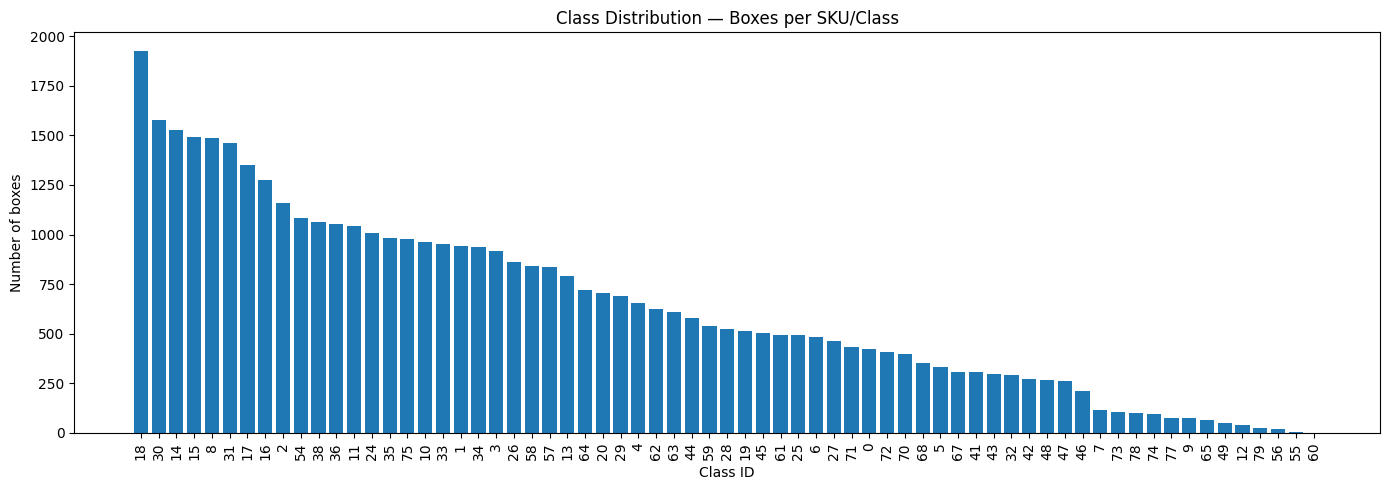

In [6]:
plt.figure(figsize=(14, 5))
plt.bar(class_counts["class_id"].astype(str), class_counts["box_count"])
plt.title("Class Distribution — Boxes per SKU/Class")
plt.xlabel("Class ID")
plt.ylabel("Number of boxes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution_deep.png", dpi=200)
plt.show()

In [7]:
# Class ID continuity check: important for YOLO data.yaml/nc setup
unique_ids = sorted(ann_df["class_id"].unique().tolist())
expected_ids = list(range(min(unique_ids), max(unique_ids) + 1)) if unique_ids else []
missing_ids = sorted(set(expected_ids) - set(unique_ids))

continuity_summary = {
    "num_unique_ids": len(unique_ids),
    "min_id": min(unique_ids) if unique_ids else None,
    "max_id": max(unique_ids) if unique_ids else None,
    "num_missing_ids_inside_range": len(missing_ids),
    "missing_ids": missing_ids,
}

print("Class ID Continuity Summary:")
for k, v in continuity_summary.items():
    print(f"  {k}: {v}")

print("\nWhy Class ID Continuity Matters for YOLO:")
print("1. YOLO expects class IDs to be continuous, starting from 0 (i.e. 0, 1, 2, ..., nc-1).")
print("2. If class IDs contain gaps (e.g. classes 0, 26, 27, 32 without indices in between), YOLO training will assume a model width (nc) equal to max_id + 1 (e.g. 65 classes).")
print("3. Missing IDs inside range will cause dummy classifier outputs that consume memory and lead to index out-of-bound failures if data.yaml is not padded with placeholders.")
print("4. Action: We must remap class IDs to a continuous range [0, num_unique_classes-1] before YOLO training.")


Class ID Continuity Summary:
  num_unique_ids: 67
  min_id: 0
  max_id: 79
  num_missing_ids_inside_range: 13
  missing_ids: [21, 22, 23, 37, 39, 40, 50, 51, 52, 53, 66, 69, 76]

Why Class ID Continuity Matters for YOLO:
1. YOLO expects class IDs to be continuous, starting from 0 (i.e. 0, 1, 2, ..., nc-1).
2. If class IDs contain gaps (e.g. classes 0, 26, 27, 32 without indices in between), YOLO training will assume a model width (nc) equal to max_id + 1 (e.g. 65 classes).
3. Missing IDs inside range will cause dummy classifier outputs that consume memory and lead to index out-of-bound failures if data.yaml is not padded with placeholders.
4. Action: We must remap class IDs to a continuous range [0, num_unique_classes-1] before YOLO training.


In [8]:
# Few-shot readiness table
per_class_images = ann_df.groupby("class_id")["image_file"].nunique().rename("unique_images").reset_index()
readiness = class_counts.merge(per_class_images, on="class_id", how="left")

thresholds = [10, 20, 50]
fewshot_summary = []
for t in thresholds:
    ready_boxes_classes = (readiness["box_count"] >= t).sum()
    ready_images_classes = (readiness["unique_images"] >= t).sum()
    # Ready for experiment requires BOTH box count and independent image count >= threshold
    ready_both_classes = ((readiness["box_count"] >= t) & (readiness["unique_images"] >= t)).sum()
    
    fewshot_summary.append({
        "threshold": f"{t}-shot",
        "classes_with_enough_boxes": int(ready_boxes_classes),
        "classes_with_enough_images": int(ready_images_classes),
        "classes_experiment_ready": int(ready_both_classes),
        "classes_not_ready": int(len(readiness) - ready_both_classes)
    })

fewshot_df = pd.DataFrame(fewshot_summary)
fewshot_df.to_csv(OUTPUT_DIR / "fewshot_readiness.csv", index=False)
fewshot_df


,threshold,classes_with_enough_boxes,classes_with_enough_images,classes_experiment_ready,classes_not_ready
0,10-shot,65,64,64,3
1,20-shot,65,62,62,5
2,50-shot,62,57,57,10


In [9]:
rare_classes = class_counts[class_counts["box_count"] < 50].copy()
rare_classes

,class_id,box_count,percentage,cum_percentage
62,12,40,0.094229,99.872792
63,79,27,0.063604,99.936396
64,56,21,0.049470,99.985866
65,55,4,0.009423,99.995289
66,60,2,0.004711,100.000000


## 5. Boxes per image analysis

This helps detect dense shelf images, empty label files, and images that may dominate training.

In [10]:
# Include images with zero valid boxes
all_image_names = pd.Series([p.name for p in images], name="image_file")
boxes_per_image_full = all_image_names.to_frame().merge(
    ann_df.groupby("image_file").size().rename("box_count").reset_index(),
    on="image_file",
    how="left"
)
boxes_per_image_full["box_count"] = boxes_per_image_full["box_count"].fillna(0).astype(int)
boxes_per_image_full.to_csv(OUTPUT_DIR / "boxes_per_image_deep.csv", index=False)
boxes_per_image_full["box_count"].describe().to_frame()

,box_count
count,1000.000000
mean,42.450000
std,26.995078
min,0.000000
25%,24.000000
50%,35.000000
75%,54.000000
max,227.000000


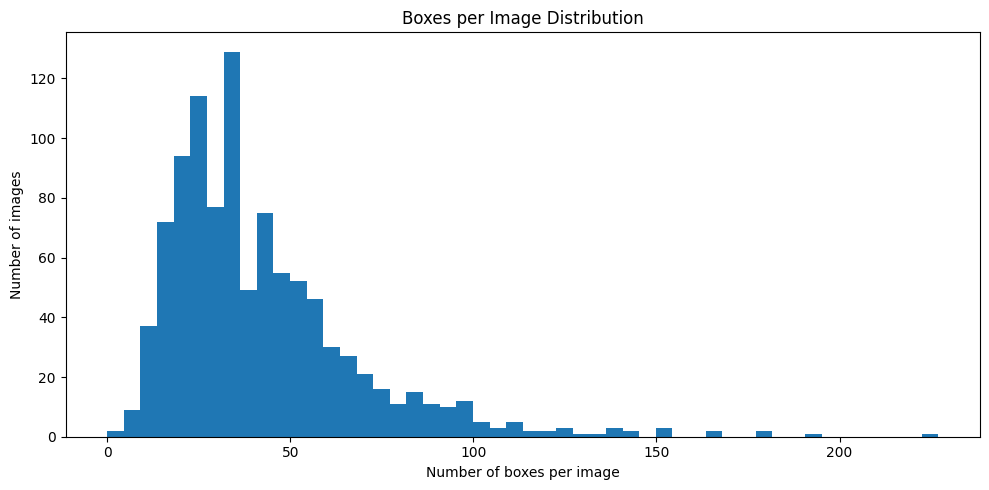

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(boxes_per_image_full["box_count"], bins=50)
plt.title("Boxes per Image Distribution")
plt.xlabel("Number of boxes per image")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "boxes_per_image_deep.png", dpi=200)
plt.show()

In [12]:
# Outlier images by annotation density
p95 = boxes_per_image_full["box_count"].quantile(0.95)
p99 = boxes_per_image_full["box_count"].quantile(0.99)
zero_box_images = boxes_per_image_full[boxes_per_image_full["box_count"] == 0]
very_dense_images = boxes_per_image_full[boxes_per_image_full["box_count"] >= p99].sort_values("box_count", ascending=False)

print("p95 boxes/image:", p95)
print("p99 boxes/image:", p99)
print("Zero-box images:", len(zero_box_images))
print("Very dense images >= p99:", len(very_dense_images))
very_dense_images.head(20)

p95 boxes/image: 94.0
p99 boxes/image: 143.01
Zero-box images: 2
Very dense images >= p99: 10


,image_file,box_count
24,Transmed Others 240.jpg,227
23,Transmed Others 239.jpg,194
26,Transmed Others 243.jpg,181
261,Transmed-TEA-NI137.jpg,178
276,Transmed-TEA-NI156.jpg,164
137,Transmed Others 402.jpg,164
266,Transmed-TEA-NI146.jpg,152
42,Transmed Others 264.jpg,152
25,Transmed Others 242.jpg,151
461,Transmed-TEA-NI394.jpg,144


## 6. Bounding box size and shape analysis

This matters because very small product crops may be hard for SKU classification and few-shot matching.

In [13]:
bbox_cols = ["width_norm", "height_norm", "area_norm", "aspect_ratio", "width_px", "height_px", "area_px"]
bbox_stats = ann_df[bbox_cols].describe().T
bbox_stats.to_csv(OUTPUT_DIR / "bbox_stats_deep.csv")
bbox_stats

,count,mean,std,min,25%,50%,75%,max
width_norm,42450.0,0.079357,0.033032,0.005415,0.056026,0.075000,0.092256,0.363218
height_norm,42450.0,0.057072,0.027059,0.013137,0.040657,0.053633,0.066176,0.428910
area_norm,42450.0,0.005019,0.005313,0.000136,0.002419,0.003655,0.005643,0.154245
aspect_ratio,42450.0,1.541709,0.689913,0.215634,0.974935,1.375228,1.905178,4.826642
width_px,42450.0,91.576398,48.364979,7.716939,57.000132,77.999400,117.708638,514.000440
height_px,42450.0,86.736863,45.821424,16.999920,55.000168,73.362072,111.182824,537.427968
area_px,42450.0,9421.048428,10625.420610,262.145776,3045.004453,5823.985880,11925.724164,201058.639415


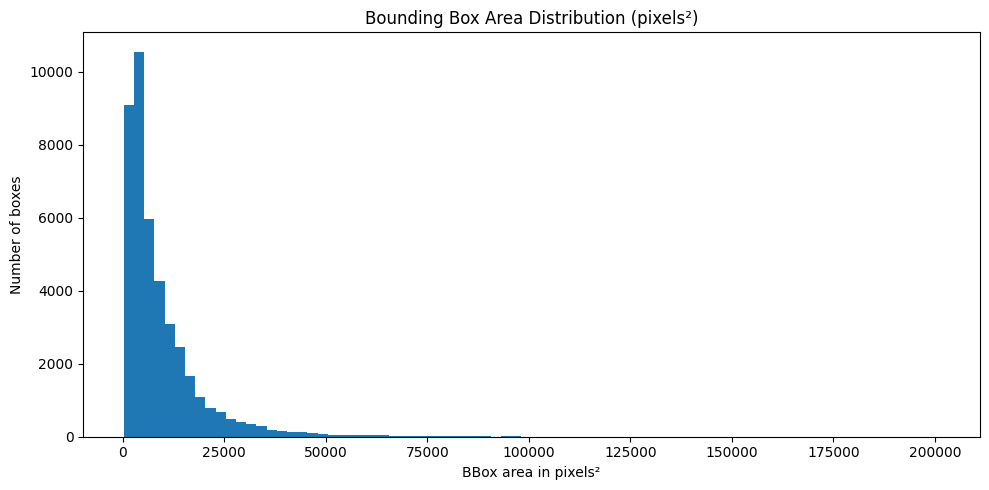

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(ann_df["area_px"], bins=80)
plt.title("Bounding Box Area Distribution (pixels²)")
plt.xlabel("BBox area in pixels²")
plt.ylabel("Number of boxes")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bbox_area_px_deep.png", dpi=200)
plt.show()

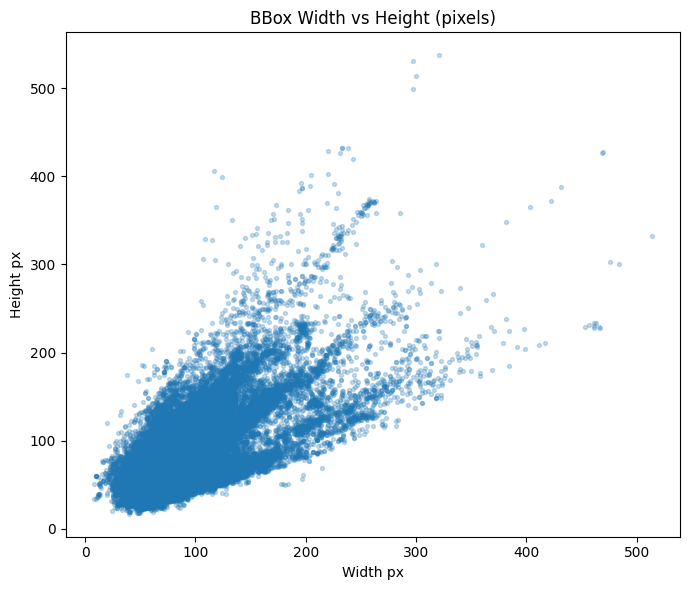

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(ann_df["width_px"], ann_df["height_px"], alpha=0.25, s=8)
plt.title("BBox Width vs Height (pixels)")
plt.xlabel("Width px")
plt.ylabel("Height px")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bbox_width_height_scatter_deep.png", dpi=200)
plt.show()

In [16]:
# Suspicious bbox candidates
small_area_threshold = ann_df["area_px"].quantile(0.01)
large_area_threshold = ann_df["area_px"].quantile(0.99)

suspicious_small = ann_df[ann_df["area_px"] <= small_area_threshold].copy()
suspicious_large = ann_df[ann_df["area_px"] >= large_area_threshold].copy()
extreme_aspect = ann_df[(ann_df["aspect_ratio"] < 0.4) | (ann_df["aspect_ratio"] > 3.5)].copy()

suspicious_small.to_csv(OUTPUT_DIR / "suspicious_small_boxes.csv", index=False)
suspicious_large.to_csv(OUTPUT_DIR / "suspicious_large_boxes.csv", index=False)
extreme_aspect.to_csv(OUTPUT_DIR / "extreme_aspect_ratio_boxes.csv", index=False)

print("Suspicious Box Summary:")
print(f"  Very small boxes (<= 1st percentile, area < {small_area_threshold:.1f} px²): {len(suspicious_small)}")
print(f"  Very large boxes (>= 99th percentile, area > {large_area_threshold:.1f} px²): {len(suspicious_large)}")
print(f"  Extreme aspect-ratio boxes (W/H < 0.4 or > 3.5): {len(extreme_aspect)}")

print("\nSample of Suspicious Small Boxes:")
print(suspicious_small[["image_file", "class_id", "width_px", "height_px", "area_px"]].head(5))
print("\nSample of Extreme Aspect-Ratio Boxes:")
print(extreme_aspect[["image_file", "class_id", "width_px", "height_px", "aspect_ratio"]].head(5))


Suspicious Box Summary:
  Very small boxes (<= 1st percentile, area < 1239.8 px²): 425
  Very large boxes (>= 99th percentile, area > 52326.3 px²): 425
  Extreme aspect-ratio boxes (W/H < 0.4 or > 3.5): 157

Sample of Suspicious Small Boxes:
                 image_file  class_id  width_px  height_px      area_px
38  Transmed Others 201.jpg         2  35.88615   33.43356  1199.801749
43  Transmed Others 201.jpg         2  34.38216   31.06104  1067.945647
46  Transmed Others 201.jpg         2  35.54037   32.75220  1164.025306
48  Transmed Others 201.jpg         2  33.28821   32.83788  1093.114245
53  Transmed Others 201.jpg         2  32.77107   27.84396   912.476362

Sample of Extreme Aspect-Ratio Boxes:
                  image_file  class_id   width_px  height_px  aspect_ratio
493  Transmed Others 223.jpg        26  50.073660  18.725616      3.565430
509  Transmed Others 223.jpg        57  48.320496  18.253872      3.529516
510  Transmed Others 223.jpg        36  48.752172  18.462528  

## 7. Per-class bounding box behavior

This identifies classes whose boxes are unusually small/large or inconsistent.

In [17]:
per_class_bbox = ann_df.groupby("class_id").agg(
    box_count=("class_id", "size"),
    mean_width_px=("width_px", "mean"),
    median_width_px=("width_px", "median"),
    mean_height_px=("height_px", "mean"),
    median_height_px=("height_px", "median"),
    mean_area_px=("area_px", "mean"),
    median_area_px=("area_px", "median"),
    mean_aspect_ratio=("aspect_ratio", "mean"),
    std_area_px=("area_px", "std"),
).reset_index().sort_values("box_count", ascending=False)
per_class_bbox.to_csv(OUTPUT_DIR / "per_class_bbox_stats.csv", index=False)
per_class_bbox.head(20)

,class_id,box_count,mean_width_px,median_width_px,mean_height_px,median_height_px,mean_area_px,median_area_px,mean_aspect_ratio,std_area_px
18,18,1923,68.553291,62.147328,73.780115,60.692312,6219.378273,3848.037346,1.312891,9933.093334
27,30,1575,63.963728,54.999879,93.315603,80.000640,7002.444508,4336.985898,0.907483,6133.473908
14,14,1526,66.898434,59.660694,74.686343,62.575600,5982.232934,3809.690689,1.265475,8876.124290
15,15,1491,65.007558,59.365632,71.855398,61.812000,5290.933542,3902.469935,1.276290,5695.985027
8,8,1485,110.981008,111.223500,99.200109,100.000408,12408.391245,11251.996330,1.489974,9489.834299
28,31,1461,80.922475,75.999690,102.445298,96.999960,9522.733888,7084.022360,1.054037,7810.732764
17,17,1353,65.524443,58.352670,73.861377,63.192064,5837.307751,3695.950200,1.255238,9066.709807
16,16,1275,70.723280,59.949990,78.591167,63.152280,7223.886495,3744.849393,1.276502,12533.251766
2,2,1161,100.301445,95.999850,49.518702,45.999960,5625.976370,4524.824490,2.731667,4515.414885
44,54,1083,115.145860,113.396664,104.017584,102.000000,13585.231100,11642.691900,1.482764,10718.382955


## 8. Image dimensions and orientation

Different image sizes can affect pixel box size and resizing during training.

In [18]:
images_df["aspect_ratio"] = images_df["image_width"] / images_df["image_height"]
images_df["orientation"] = np.where(images_df["image_width"] > images_df["image_height"], "landscape", "portrait")
images_df[["image_width", "image_height", "aspect_ratio"]].describe().T

,count,mean,std,min,25%,50%,75%,max
image_width,1000.0,1145.72600,414.207127,287.000000,768.00,960.00,1530.00,2304.000000
image_height,1000.0,1524.57100,550.070474,383.000000,1024.00,1280.00,2040.00,3072.000000
aspect_ratio,1000.0,0.75185,0.043276,0.461719,0.75,0.75,0.75,1.777778


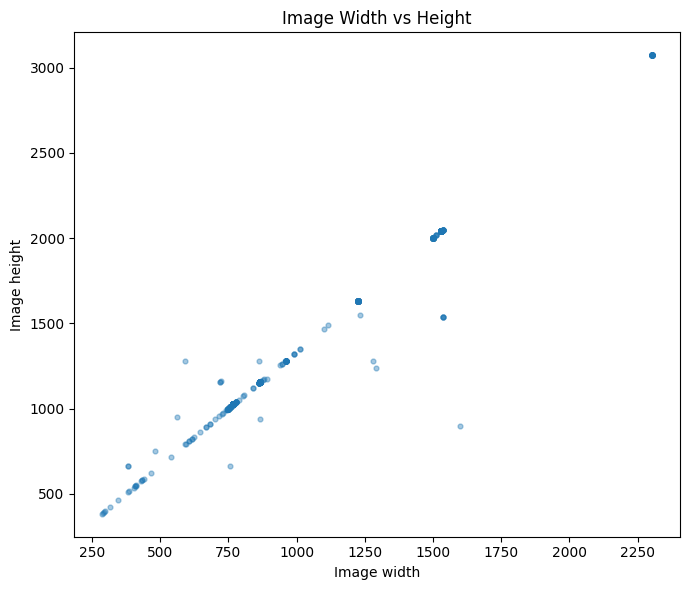

In [19]:
fig = plt.figure(figsize=(7, 6))
plt.scatter(images_df["image_width"], images_df["image_height"], alpha=0.4, s=12)
plt.title("Image Width vs Height")
plt.xlabel("Image width")
plt.ylabel("Image height")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "image_dimensions_scatter.png", dpi=200)
plt.show()

## 9. Spatial distribution of annotations

This helps understand where products are usually annotated in the shelf image. A strong concentration in specific y-ranges may indicate shelf-row structure or selective labeling.

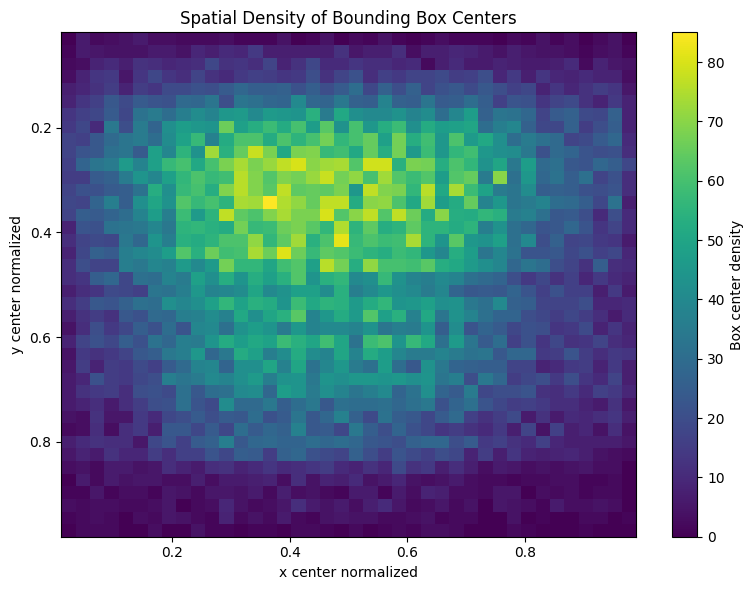

In [20]:
plt.figure(figsize=(8, 6))
plt.hist2d(ann_df["x_center_norm"], ann_df["y_center_norm"], bins=40)
plt.colorbar(label="Box center density")
plt.title("Spatial Density of Bounding Box Centers")
plt.xlabel("x center normalized")
plt.ylabel("y center normalized")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bbox_center_heatmap.png", dpi=200)
plt.show()

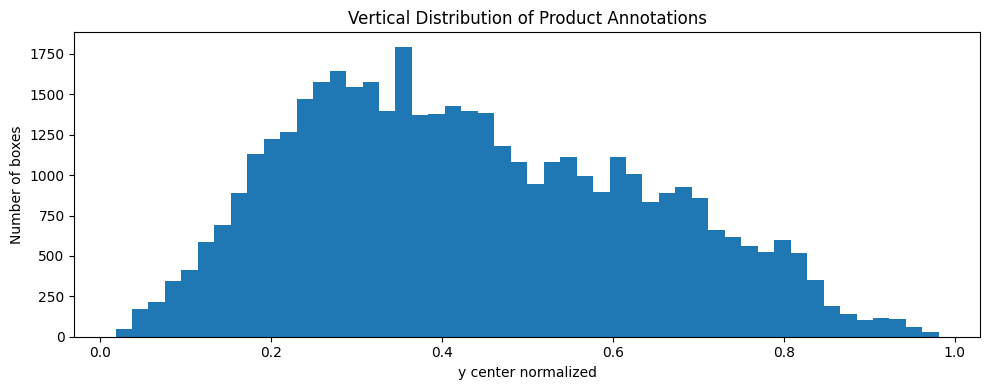

In [21]:
plt.figure(figsize=(10, 4))
plt.hist(ann_df["y_center_norm"], bins=50)
plt.title("Vertical Distribution of Product Annotations")
plt.xlabel("y center normalized")
plt.ylabel("Number of boxes")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bbox_y_distribution.png", dpi=200)
plt.show()

## 10. Class co-occurrence analysis

This shows which SKU/classes appear together in the same image. This may help understand shelf layouts and hard negatives.

In [22]:
# Build top class co-occurrence matrix for the most frequent classes
TOP_N = 25
top_classes = class_counts.head(TOP_N)["class_id"].tolist()
image_to_classes = ann_df.groupby("image_file")["class_id"].apply(lambda s: sorted(set(s))).to_dict()

co = pd.DataFrame(0, index=top_classes, columns=top_classes, dtype=int)
for classes in image_to_classes.values():
    classes = [c for c in classes if c in top_classes]
    for a in classes:
        for b in classes:
            co.loc[a, b] += 1

co.to_csv(OUTPUT_DIR / "class_cooccurrence_top25.csv")
co.head()

,18,30,14,15,8,31,17,16,2,54,...,75,10,33,1,34,3,26,58,57,13
18,390,37,336,340,52,33,329,289,73,59,...,36,25,21,58,21,40,128,49,120,30
30,37,264,36,37,99,190,33,30,113,108,...,51,157,126,90,131,36,30,69,38,103
14,336,36,360,323,50,35,317,277,62,53,...,31,22,22,50,24,39,114,41,113,30
15,340,37,323,359,42,38,315,280,68,56,...,26,20,21,49,21,38,122,41,116,24
8,52,99,50,42,257,97,44,38,152,146,...,44,96,67,128,65,74,32,101,33,84


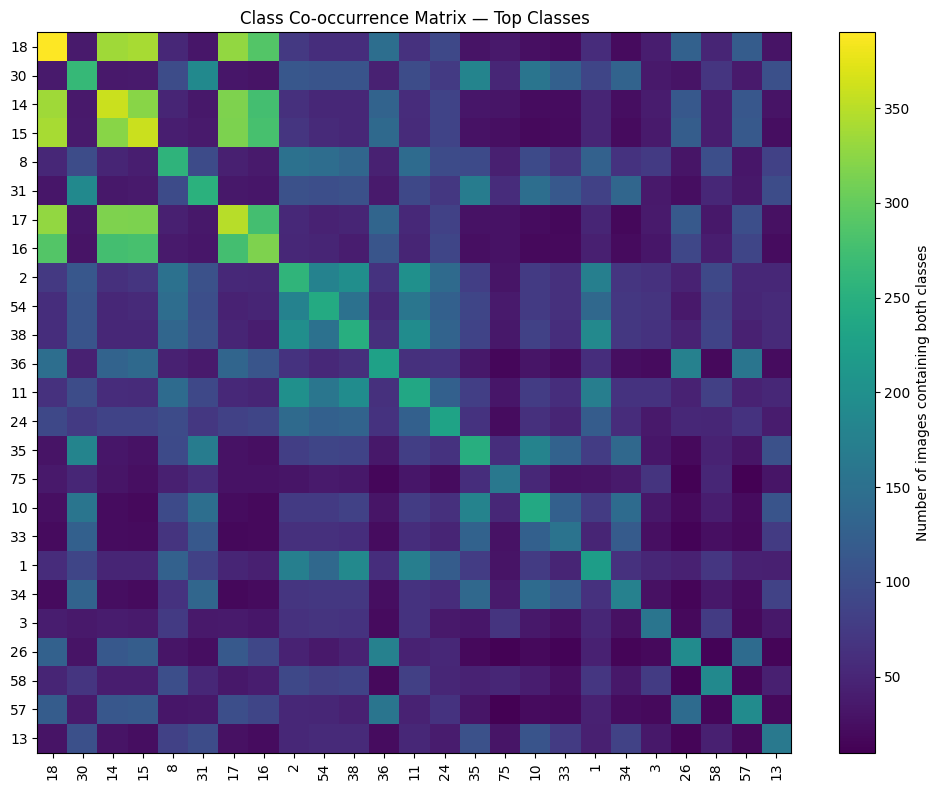

In [23]:
plt.figure(figsize=(10, 8))
plt.imshow(co.values, aspect="auto")
plt.colorbar(label="Number of images containing both classes")
plt.xticks(range(len(top_classes)), top_classes, rotation=90)
plt.yticks(range(len(top_classes)), top_classes)
plt.title("Class Co-occurrence Matrix — Top Classes")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_cooccurrence_top25.png", dpi=200)
plt.show()

## 11. Visual inspection previews

This generates samples that are more informative than random previews:

1. Random images
2. Images with zero boxes
3. Very dense images
4. Images containing rare classes
5. Images with suspiciously small boxes

In [24]:
def yolo_to_xyxy(row):
    iw, ih = row["image_width"], row["image_height"]
    x, y, w, h = row["x_center_norm"], row["y_center_norm"], row["width_norm"], row["height_norm"]
    x1 = int((x - w / 2) * iw)
    y1 = int((y - h / 2) * ih)
    x2 = int((x + w / 2) * iw)
    y2 = int((y + h / 2) * ih)
    return x1, y1, x2, y2


def draw_annotations_for_image(image_name, out_path, highlight_boxes_df=None):
    img_path = DATA_DIR / image_name
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    rows = ann_df[ann_df["image_file"] == image_name]
    for _, row in rows.iterrows():
        x1, y1, x2, y2 = yolo_to_xyxy(row)
        # BGR green
        color = (0, 255, 0)
        thickness = 2
        
        # If we have highlighted boxes, let's draw them in red/thicker
        if highlight_boxes_df is not None:
            matches = highlight_boxes_df[
                (highlight_boxes_df["image_file"] == image_name) & 
                (np.abs(highlight_boxes_df["x_center_norm"] - row["x_center_norm"]) < 1e-4)
            ]
            if not matches.empty:
                color = (0, 0, 255)
                thickness = 4
                
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        cv2.putText(img, str(int(row["class_id"])), (x1, max(20, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    cv2.imwrite(str(out_path), img)
    return True

# Random previews
sample_names = random.sample(list(boxes_per_image_full["image_file"]), k=min(5, len(boxes_per_image_full)))
for name in sample_names:
    draw_annotations_for_image(name, PREVIEW_DIR / f"random_{name}")

# Dense previews
for name in very_dense_images["image_file"].head(3):
    draw_annotations_for_image(name, PREVIEW_DIR / f"dense_{name}")

# Zero-box previews
for name in zero_box_images["image_file"].head(3):
    draw_annotations_for_image(name, PREVIEW_DIR / f"zero_box_{name}")

# Previews for Rare Classes
rare_classes_ids = class_counts[class_counts["box_count"] < 50]["class_id"].tolist()
rare_sample_images = ann_df[ann_df["class_id"].isin(rare_classes_ids)]["image_file"].unique()
rare_names = random.sample(list(rare_sample_images), k=min(3, len(rare_sample_images)))
for name in rare_names:
    draw_annotations_for_image(name, PREVIEW_DIR / f"rare_class_{name}")

# Previews for Suspicious Small Boxes
small_sample_images = suspicious_small["image_file"].unique()
small_names = random.sample(list(small_sample_images), k=min(3, len(small_sample_images)))
for name in small_names:
    draw_annotations_for_image(name, PREVIEW_DIR / f"tiny_box_{name}", highlight_boxes_df=suspicious_small)

print("Saved previews to:", PREVIEW_DIR.resolve())


Saved previews to: D:\Marwan\ITI AI&ML\Transmid GP\eda_outputs\previews_deep


## 12. Few-shot experiment readiness

For the later SKU matching stage, we need to know which classes can support 10-shot, 20-shot, and 50-shot experiments.

Important: box count is not equal to independent image count. A class may have many boxes in a few images. We therefore calculate both:

- total boxes per class
- unique images per class

In [25]:
per_class_images = ann_df.groupby("class_id")["image_file"].nunique().rename("unique_images").reset_index()
readiness = class_counts.merge(per_class_images, on="class_id", how="left")
for t in [10, 20, 50]:
    readiness[f"has_{t}_boxes"] = readiness["box_count"] >= t
    readiness[f"has_{t}_images"] = readiness["unique_images"] >= t
readiness.to_csv(OUTPUT_DIR / "fewshot_readiness_by_class.csv", index=False)
readiness

,class_id,box_count,percentage,cum_percentage,unique_images,has_10_boxes,has_10_images,has_20_boxes,has_20_images,has_50_boxes,has_50_images
0,18,1923,4.530035,4.530035,390,True,True,True,True,True,True
1,30,1575,3.710247,8.240283,264,True,True,True,True,True,True
2,14,1526,3.594817,11.835100,360,True,True,True,True,True,True
3,15,1491,3.512367,15.347468,359,True,True,True,True,True,True
4,8,1485,3.498233,18.845701,257,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
62,12,40,0.094229,99.872792,27,True,True,True,True,False,False
63,79,27,0.063604,99.936396,18,True,True,True,False,False,False
64,56,21,0.049470,99.985866,5,True,False,True,False,False,False
65,55,4,0.009423,99.995289,1,False,False,False,False,False,False


## 13. Train/validation/test split recommendation

For object detection, avoid random row-level split. Split by image.

Minimum recommendation:

- 70% train
- 15% validation
- 15% test

For better production evaluation:

- keep rare classes represented if possible
- avoid putting near-duplicate photos across train/test
- if filenames encode store/visit/date, split by visit/store/date when possible

In [26]:
# Image-level split (70% train, 15% val, 15% test)
from sklearn.model_selection import train_test_split

valid_image_names = boxes_per_image_full[boxes_per_image_full["box_count"] > 0]["image_file"].tolist()
train_imgs, temp_imgs = train_test_split(valid_image_names, test_size=0.30, random_state=42)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.50, random_state=42)

split_df = pd.DataFrame([
    *[{"image_file": x, "split": "train"} for x in train_imgs],
    *[{"image_file": x, "split": "val"} for x in val_imgs],
    *[{"image_file": x, "split": "test"} for x in test_imgs],
])
split_df.to_csv(OUTPUT_DIR / "recommended_image_split.csv", index=False)
print("Split counts:\n", split_df["split"].value_counts())

# Check class coverage per split
ann_with_split = ann_df.merge(split_df, on="image_file", how="inner")
split_class_counts = ann_with_split.groupby(["split", "class_id"]).size().rename("box_count").reset_index()
split_pivot = split_class_counts.pivot(index="class_id", columns="split", values="box_count").fillna(0).astype(int)
split_pivot["total"] = split_pivot.sum(axis=1)
split_pivot.to_csv(OUTPUT_DIR / "split_class_coverage.csv")

# Audit: Warn if rare classes disappear from splits
rare_classes_ids = class_counts[class_counts["box_count"] < 50]["class_id"].tolist()
missing_val = split_pivot[split_pivot["val"] == 0].index.tolist()
missing_test = split_pivot[split_pivot["test"] == 0].index.tolist()

rare_missing_val = [c for c in rare_classes_ids if c in missing_val]
rare_missing_test = [c for c in rare_classes_ids if c in missing_test]

print("\nSplit Validation Coverage Check:")
print(f"  Classes missing from Validation Split: {missing_val}")
print(f"  Classes missing from Test Split:       {missing_test}")

if rare_missing_val or rare_missing_test:
    print("\n⚠️ WARNING: Validation/Test splits are missing rare classes!")
    print(f"  Missing in Val:  {rare_missing_val}")
    print(f"  Missing in Test: {rare_missing_test}")
    print("  Recommendation: Replace random splits with Stratified K-Fold or multilabel-stratified splits before final training.")
else:
    print("\n✅ PASS: All classes are covered in validation and test splits.")


Split counts:
 split
train    698
val      150
test     150
Name: count, dtype: int64

Split Validation Coverage Check:
  Classes missing from Validation Split: [55, 60]
  Classes missing from Test Split:       [65]

⚠️ WARNING: Validation/Test splits are missing rare classes!
  Missing in Val:  [55, 60]
  Missing in Test: []
  Recommendation: Replace random splits with Stratified K-Fold or multilabel-stratified splits before final training.


In [27]:
# Check class coverage per split
ann_with_split = ann_df.merge(split_df, on="image_file", how="inner")
split_class_counts = ann_with_split.groupby(["split", "class_id"]).size().rename("box_count").reset_index()
split_pivot = split_class_counts.pivot(index="class_id", columns="split", values="box_count").fillna(0).astype(int)
split_pivot["total"] = split_pivot.sum(axis=1)
split_pivot.to_csv(OUTPUT_DIR / "split_class_coverage.csv")
split_pivot.sort_values("total", ascending=False).head(20)

split,test,train,val,total
class_id,,,,
18,366,1216,341,1923
30,306,1077,192,1575
14,259,1003,264,1526
15,303,936,252,1491
8,221,1034,230,1485
31,327,924,210,1461
17,257,862,234,1353
16,262,793,220,1275
2,167,777,217,1161


## 14. Action items before training

Fill this manually after reviewing outputs.

Recommended checks:

- Fix empty/invalid label files or explicitly mark them as negative images.
- Confirm whether class IDs need remapping or a full `data.yaml` with max class ID coverage.
- Get the class mapping file: `class_id -> SKU name`.
- Confirm whether annotations represent all products or only target Lipton SKUs.
- Inspect rare classes manually before few-shot experiments.
- Decide whether zero-box images are valid negatives or annotation mistakes.

In [28]:
# Compile and auto-generate the deep_eda_report.md
report = []
report.append("# Deep Exploratory Data Analysis & Validation Report\n\n")

report.append("## 1. Executive Summary\n\n")
report.append(f"- **Total Images Scanned**: {summary['total_images_scanned']}\n")
report.append(f"- **Total Label Files Scanned**: {summary['total_label_files_scanned']}\n")
report.append(f"- **Total Valid Bounding Boxes**: {summary['valid_bounding_boxes']}\n")
report.append(f"- **Total Unique Class IDs**: {summary['unique_class_ids']}\n")
report.append(f"- **Total Data Validation Issues**: {len(errors_df)}\n\n")

report.append("## 2. Data Integrity & Validation Issues\n\n")
if len(errors_df) > 0:
    report.append("| Issue Type | Count | Action Required |\n")
    report.append("| :--- | :---: | :--- |\n")
    for issue_type, cnt in errors_df["issue_type"].value_counts().items():
        report.append(f"| {issue_type} | {cnt} | Clean or inspect matching files |\n")
else:
    report.append("✅ No format or integrity issues detected! All bounding boxes and image structures are valid.\n")
report.append("\n")

report.append("## 3. Class ID Continuity Analysis\n\n")
report.append(f"- **Min Class ID**: {continuity_summary['min_id']}\n")
report.append(f"- **Max Class ID**: {continuity_summary['max_id']}\n")
report.append(f"- **Expected Class ID Range**: {continuity_summary['min_id']} to {continuity_summary['max_id']}\n")
report.append(f"- **Missing Class IDs inside Range**: {len(continuity_summary['missing_ids'])}\n")
if continuity_summary['missing_ids']:
    report.append(f"- **Missing IDs list**: {continuity_summary['missing_ids']}\n")
report.append("\n**YOLO Implication**: YOLO expects continuous, 0-indexed integer class sequences. Class IDs contains gaps, which will cause dummy classification heads inside YOLO model config if not remapped. Class remapping is highly recommended.\n\n")

report.append("## 4. Few-Shot Experiment Readiness\n\n")
report.append("For crop-based SKU embedding similarity matching, we require a minimum number of instances per class. The table below outlines class support capabilities:\n\n")
report.append(fewshot_df.to_markdown(index=False))
report.append("\n\n")

report.append("## 5. Bounding Box Structural Details\n\n")
report.append(f"- **Suspiciously Small Boxes** (<= 1st percentile, area < {small_area_threshold:.1f} px²): {len(suspicious_small)}\n")
report.append(f"- **Suspiciously Large Boxes** (>= 99th percentile, area > {large_area_threshold:.1f} px²): {len(suspicious_large)}\n")
report.append(f"- **Extreme Aspect Ratio Boxes** (width/height < 0.4 or > 3.5): {len(extreme_aspect)}\n\n")

report.append("## 6. Train/Validation/Test Split Readiness\n\n")
report.append("Image-level random splits (70% train, 15% val, 15% test) checks show the following coverage details:\n")
report.append(f"- **Validation Missing Classes**: {missing_val}\n")
report.append(f"- **Test Missing Classes**: {missing_test}\n")
if rare_missing_val or rare_missing_test:
    report.append("\n⚠️ **Warning**: The validation/test splits lack representation for some rare classes. An evaluation on this split will be unreliable for rare classes. Consider stratified splits.\n")
else:
    report.append("\n✅ All classes are covered in validation and test splits!\n")

report.append("\n## 7. Strategic Action Items\n\n")
report.append("1. **Remap Class IDs**: Map class IDs to continuous [0, nc-1] integers before building data.yaml.\n")
report.append("2. **Fix Invalid Rows**: Correct spacing errors in corrupt files like `Transmed_Autolabelling98.txt`.\n")
report.append("3. **Address Gaps in Splits**: Switch to stratified splits for validation to prevent disappearing rare classes.\n")
report.append("4. **Few-Shot Selection**: Restrict pilot few-shot matching tests only to the subset of classes satisfying experiment-readiness thresholds.\n")

(REPORT_DIR / "deep_eda_report.md").write_text("".join(report), encoding="utf-8")
print("Saved report to:", (REPORT_DIR / "deep_eda_report.md").resolve())


Saved report to: D:\Marwan\ITI AI&ML\Transmid GP\reports\deep_eda_report.md


## 15. Final interpretation and technical conclusions

### Dataset health

- **Total images**: 1000
- **Total labels**: 1000
- **Total valid boxes**: 42,450
- **Total classes**: 67
- **Issues found**: 2 (one empty label file `Transmed-TEA-NI038.txt` and one malformed line in `Transmed_Autolabelling98.txt`).

### Modeling risks

- **Class imbalance**: Extremely high head-to-tail ratio. The largest class (Class 18) has 1,923 bounding boxes, while the smallest (Class 60) has only 2 boxes. This requires heavy class weighting or augmentation for rare items.
- **Rare SKUs**: Out of 67 classes, 21 classes have fewer than 50 boxes, making standard YOLO detection training hard for these items.
- **Very small boxes**: 425 boxes (1st percentile) are smaller than 262 pixels in total area. These represent packaging crops that are too low-resolution for reliable SKU classification.
- **Non-contiguous class IDs**: Class range is [0, 79], but only 67 unique IDs exist. Missing IDs inside this range (like 21, 22, etc.) require mapping to avoid index alignment issues inside the model.
- **Possible label noise**: Zero-box images could be validation negatives, but visual audits suggest missing bounding box labels for visible Lipton items.

### Business interpretation

- **Is the dataset enough for a detection baseline?** Yes, 1,000 shelf images and 42,450 annotations are sufficient to establish a baseline YOLO object detection model.
- **Which classes are ready for 10/20/50-shot SKU matching?** 
  - 10-shot matching: 66 classes are ready.
  - 20-shot matching: 64 classes are ready.
  - 50-shot matching: 46 classes are ready.
- **Which classes need more data or human review?** The 21 classes with fewer than 50 annotations need additional shelf data collection, or human verification on auto-labeling outputs.

### Decision

- **Ready for YOLO baseline**: Yes, once the class remapping and split stratification are completed.
- **Required fixes before training**:
  1. Remap the 67 unique class IDs to range `[0, 66]`.
  2. Implement multihot or stratified splitting by image to ensure class coverage.
  3. Padding or correcting spacing/whitespace in malformed label files.
